# NYC Airbnb SQL + Visualization Dashboard

## 1. Database Connection
## 2. Data Validation

In [21]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

conn = sqlite3.connect("/Users/zeynep/Desktop/python-sql-practice/database/nyc.db")
pd.read_sql("SELECT COUNT(*) AS total_rows FROM airbnb_listings;", conn)




,total_rows
0,12720


## 3. Average Price by Neighbourhood

In [ ]:
q1 = """
SELECT neighbourhood_group,
       COUNT(*) AS listing_count,
       AVG(price) AS avg_price
FROM airbnb_listings
GROUP BY neighbourhood_group
ORDER BY avg_price DESC;
"""

df_q1 = pd.read_sql(q1, conn)
df_q1

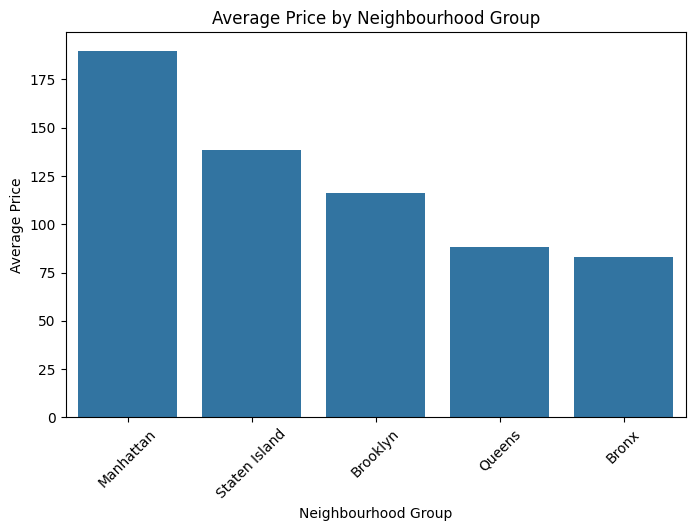

In [2]:
plt.figure(figsize=(8,5))
sns.barplot(data=df_q1, x="neighbourhood_group", y="avg_price")
plt.title("Average Price by Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.show()

## 4. Most Expensive Listings

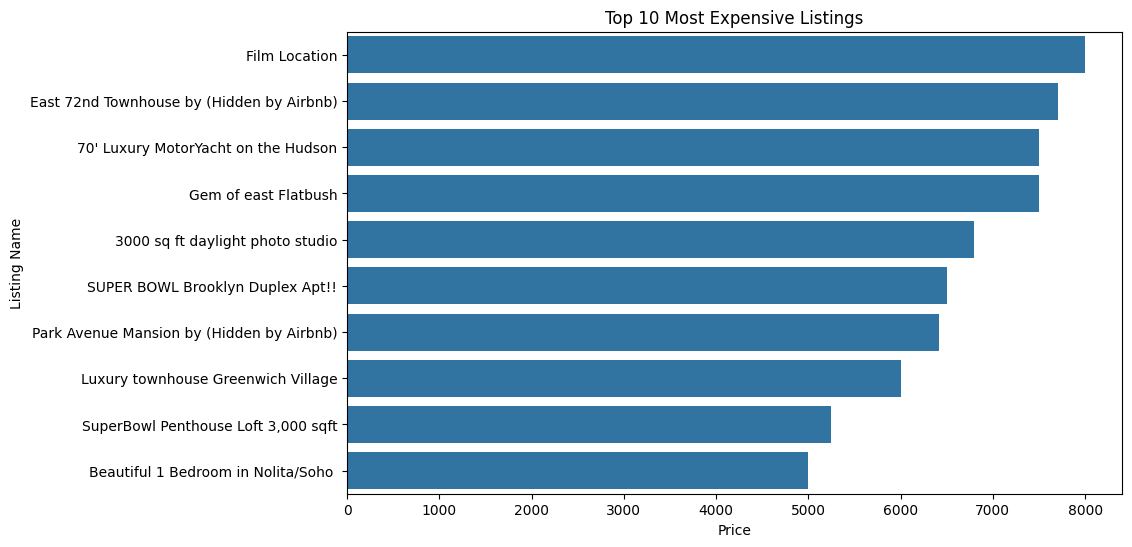

In [4]:
q2 = """
SELECT name, neighbourhood_group, price
FROM airbnb_listings
ORDER BY price DESC
LIMIT 10;
"""

df_q2 = pd.read_sql(q2, conn)
df_q2

plt.figure(figsize=(10,6))
sns.barplot(data=df_q2, x="price", y="name")
plt.title("Top 10 Most Expensive Listings")
plt.xlabel("Price")
plt.ylabel("Listing Name")
plt.show()

## 5. Most Active Hosts

In [8]:
q3 = """
SELECT host_id, host_name, COUNT(*) AS listing_count
FROM airbnb_listings
GROUP BY host_id, host_name
ORDER BY listing_count DESC
LIMIT 10;
"""

df_q3 = pd.read_sql(q3, conn)
df_q3



,host_id,host_name,listing_count
0,213781715,Anting,33
1,224414117,Gabriel,30
2,252604696,Erin,20
3,134184451,Hillside Hotel,18
4,159091490,Melissa,17
5,177174475,Alberto,17
6,201015598,Anchor,16
7,6885157,Randy,15
8,260639745,Manhattan At Times Square,15
9,260425153,Park Lane,14


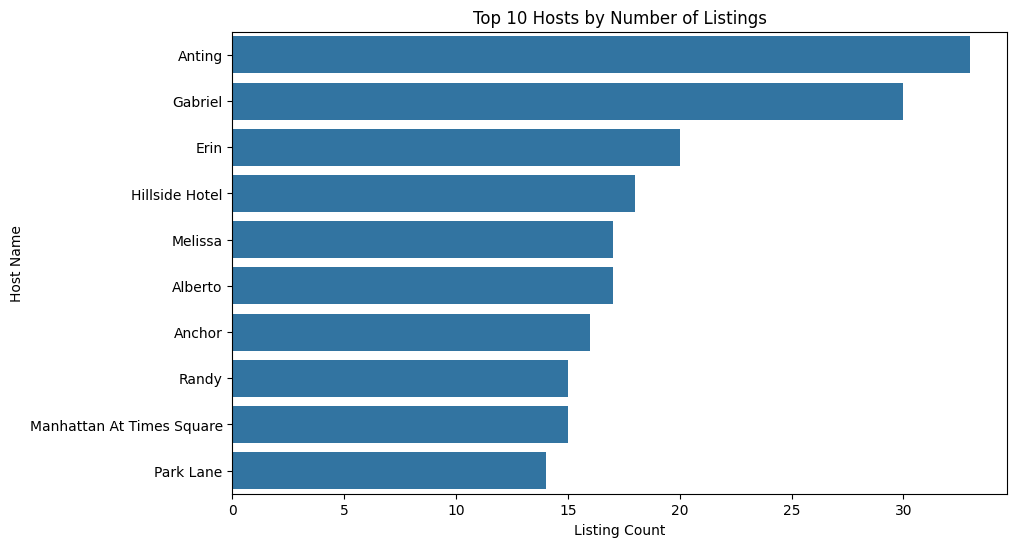

In [9]:
plt.figure(figsize=(10,6))
sns.barplot(data=df_q3, x="listing_count", y="host_name")
plt.title("Top 10 Hosts by Number of Listings")
plt.xlabel("Listing Count")
plt.ylabel("Host Name")
plt.show()

## 4. Affordable but Popular Listings

In [10]:
q4 = """
SELECT name, neighbourhood_group, price, number_of_reviews, price_per_review
FROM airbnb_listings
WHERE price < 100
  AND number_of_reviews > 50
ORDER BY price_per_review ASC
LIMIT 10;
"""

df_q4 = pd.read_sql(q4, conn)
df_q4

,name,neighbourhood_group,price,number_of_reviews,price_per_review
0,Spacious comfortable master bedroom with nice ...,Brooklyn,0,93,0.000000
1,Contemporary bedroom in brownstone with nice view,Brooklyn,0,95,0.000000
2,Cozy yet spacious private brownstone bedroom,Brooklyn,0,95,0.000000
3,Room near JFK Queen Bed,Queens,47,629,0.074603
4,Space to rest near LaGuardia Airport,Queens,32,411,0.077670
5,Great Bedroom in Manhattan,Manhattan,49,607,0.080592
6,Room Near JFK Twin Beds,Queens,47,576,0.081456
7,Beautiful Bedroom in Manhattan,Manhattan,49,597,0.081940
8,Private Bedroom in Manhattan,Manhattan,49,594,0.082353
9,Steps away from Laguardia airport,Queens,46,543,0.084559


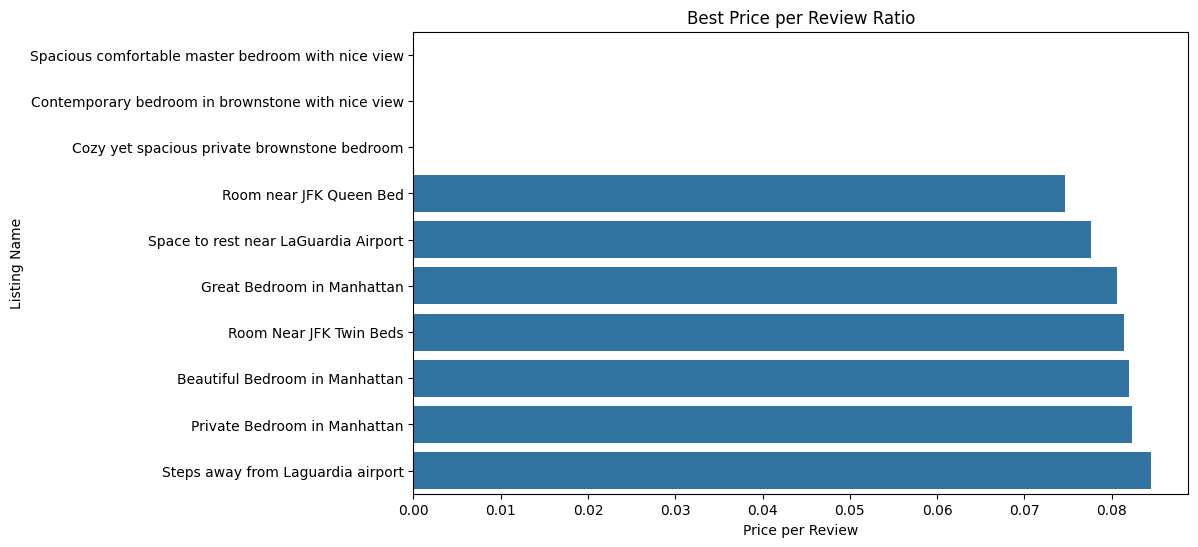

In [11]:
plt.figure(figsize=(10,6))
sns.barplot(data=df_q4, x="price_per_review", y="name")
plt.title("Best Price per Review Ratio")
plt.xlabel("Price per Review")
plt.ylabel("Listing Name")
plt.show()

## 5. Price Category Distribution

In [12]:
q5 = """
SELECT price_category, COUNT(*) AS listing_count
FROM airbnb_listings
GROUP BY price_category
ORDER BY listing_count DESC;
"""

df_q5 = pd.read_sql(q5, conn)
df_q5

,price_category,listing_count
0,Cheap,7033
1,Medium,3814
2,Expensive,1873


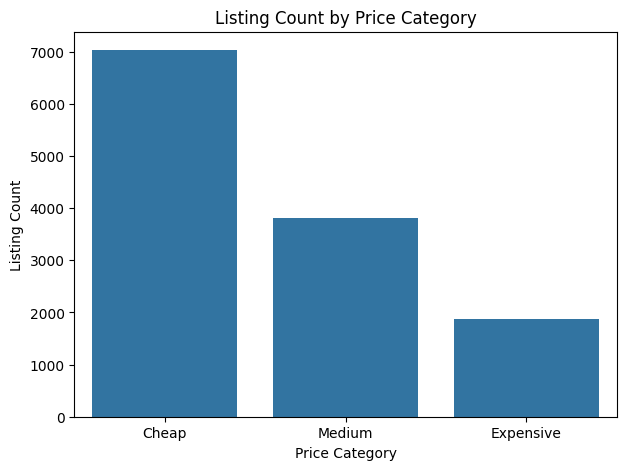

In [13]:
plt.figure(figsize=(7,5))
sns.barplot(data=df_q5, x="price_category", y="listing_count")
plt.title("Listing Count by Price Category")
plt.xlabel("Price Category")
plt.ylabel("Listing Count")
plt.show()

## 6. Most Expensive Listing in Each Neighbourhood Group

In [ ]:
q6 = """
SELECT name, neighbourhood_group, price
FROM (
    SELECT name,
           neighbourhood_group,
           price,
           RANK() OVER (
               PARTITION BY neighbourhood_group
               ORDER BY price DESC
           ) AS rnk
    FROM airbnb_listings
)
WHERE rnk = 1;
"""

df_q6 = pd.read_sql(q6, conn)
df_q6

,name,neighbourhood_group,price
0,VJ'S 5 HOUR YACHT TOUR,Bronx,1000
1,Film Location,Brooklyn,8000
2,East 72nd Townhouse by (Hidden by Airbnb),Manhattan,7703
3,wait until later,Queens,2000
4,Victorian Film location,Staten Island,5000


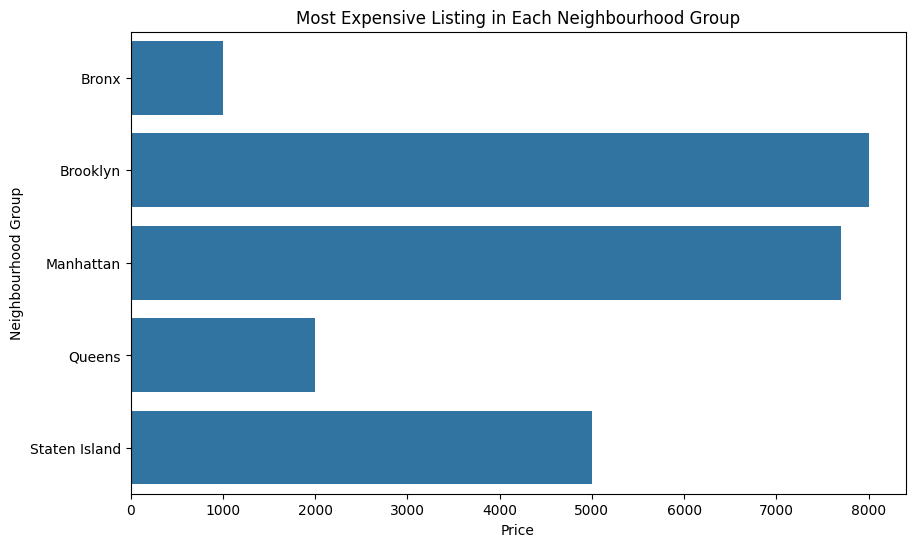

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data=df_q6, x="price", y="neighbourhood_group")
plt.title("Most Expensive Listing in Each Neighbourhood Group")
plt.xlabel("Price")
plt.ylabel("Neighbourhood Group")
plt.show()



## 7. Price count above average

In [ ]:
q7 = """
SELECT COUNT(*) AS above_avg_price_count
FROM airbnb_listings
WHERE price > (
    SELECT AVG(price)
    FROM airbnb_listings
);
"""

df_q7 = pd.read_sql(q7, conn)
df_q7

,above_avg_price_count
0,3403


In [20]:
conn.close()

## 8. Final Insights

* Manhattan and Brooklyn appear to dominate the market in both listing volume and pricing.
* A small number of hosts manage a disproportionately high number of listings, suggesting commercial activity.
* Some low-priced listings also have high review counts, indicating strong price-performance value.
* Price categories are not evenly distributed, which may reflect demand concentration in certain neighbourhoods.